In [1]:
import pandas as pd
import numpy as np

# 1. Dataset Load karna
# Agar aapne pichle step mein file save ki thi, toh wahi load karein
file_path = "data_clean.csv" 

df_final_clean = pd.read_csv(file_path)
print(f"✅ Data successfully loaded from {file_path}")
print(f"Dataset Shape: {df_final_clean.shape}")



✅ Data successfully loaded from data_clean.csv
Dataset Shape: (998, 19)



--- 📝 Text Quality & Jargon Analysis ---


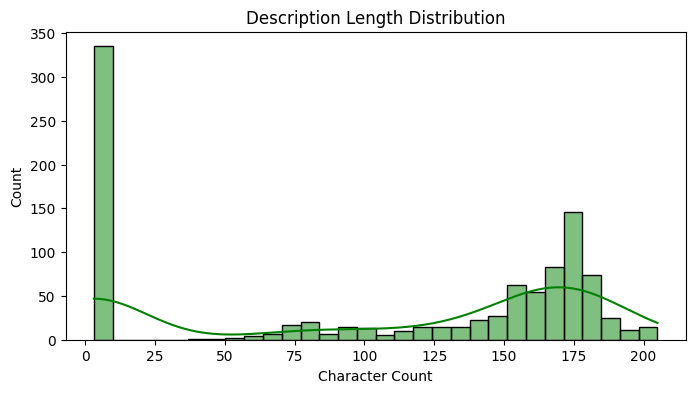

C:\Users\LAIBA\AppData\Local\Temp\ipykernel_10064\1905777168.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')


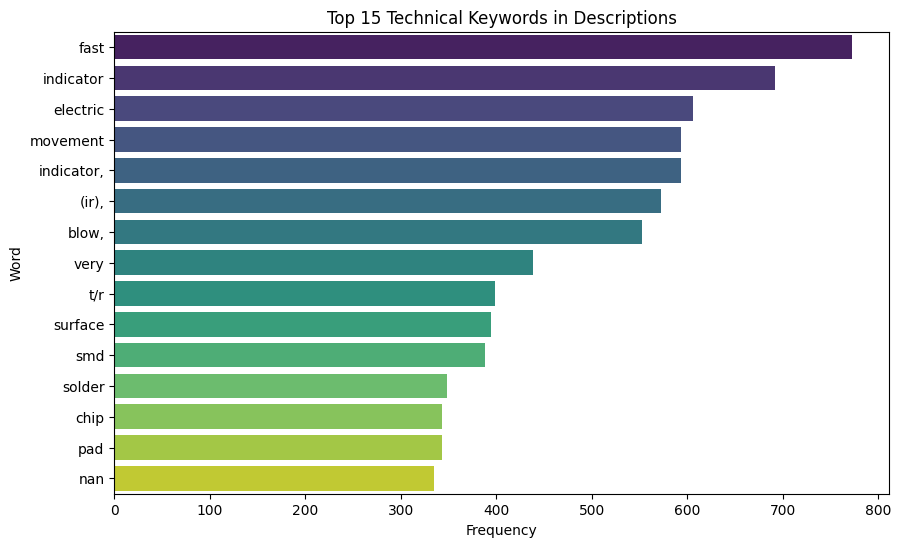

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- REVISED TEXT EDA (No WordCloud Required) ---
def text_eda_no_cloud(df):
    print("\n--- 📝 Text Quality & Jargon Analysis ---")
    
    # 1. Description Length Distribution
    df['desc_len'] = df['DESCRIPTION'].astype(str).str.len()
    plt.figure(figsize=(8, 4))
    sns.histplot(df['desc_len'], bins=30, color='green', kde=True)
    plt.title('Description Length Distribution')
    plt.xlabel('Character Count')
    plt.show()
    
    # 2. Most Frequent Technical Words (N-gram Lite)
    all_text = " ".join(df['DESCRIPTION'].astype(str)).lower().split()
    # Common English words (stop words) ko nikalne ke liye
    stop_words = {'and', 'the', 'with', 'for', 'this', 'that', 'from', 'specified', 'not'}
    clean_words = [w for w in all_text if w not in stop_words and len(w) > 2]
    
    common_words = Counter(clean_words).most_common(15)
    words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')
    plt.title('Top 15 Technical Keywords in Descriptions')
    plt.show()

# Run this instead of the previous text_eda
text_eda_no_cloud(df_final_clean)

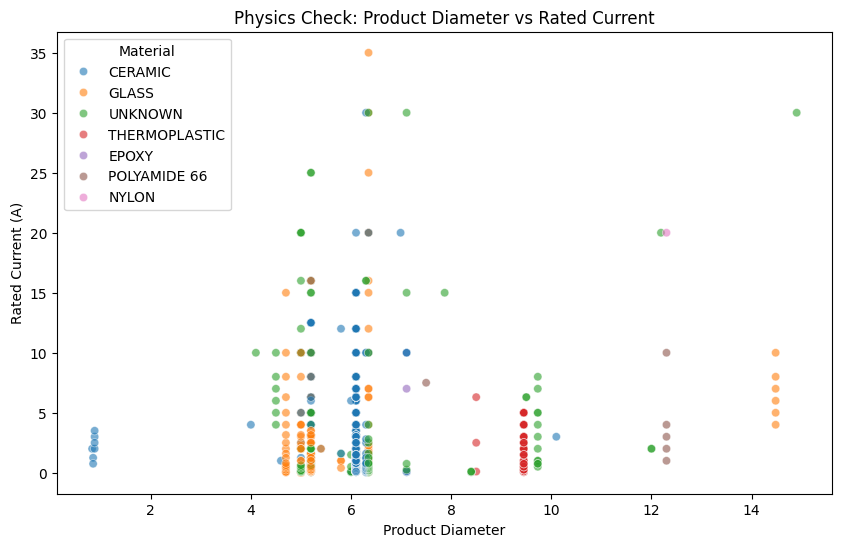

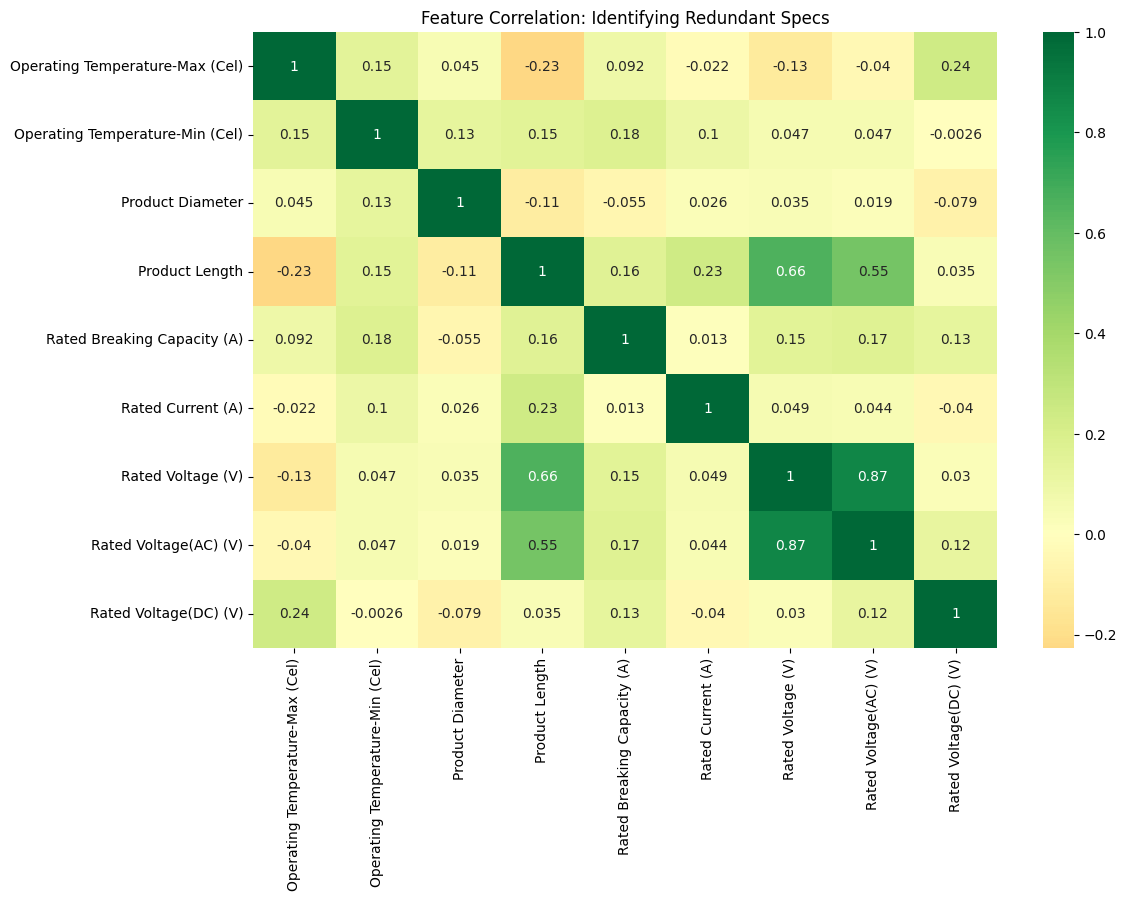

--- 🚀 RAG Readiness Report ---
Unique Description Ratio: 0.58
✅ Descriptions are diverse enough for Semantic Search.

Total Statistical Outliers (Z-score > 3): 24


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data again for fresh start
df = pd.read_csv("data_clean.csv")

# --- 1. MULTIVARIATE OUTLIER ANALYSIS (Scatter Plots) ---
# Fuses ki physics check karte hain: Size vs Current
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Product Diameter', y='Rated Current (A)', hue='Material', alpha=0.6)
plt.title("Physics Check: Product Diameter vs Rated Current")
# Agar koi dot upar-left corner mein hai (Small diameter, Huge current), wo outlier hai.
plt.show()

# --- 2. ADVANCED CORRELATION (Heatmap) ---
plt.figure(figsize=(12, 8))
# Numeric columns select karein
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Feature Correlation: Identifying Redundant Specs")
plt.show()

# --- 3. RAG READINESS: Description Uniqueness ---
unique_ratio = df['DESCRIPTION'].nunique() / len(df)
print(f"--- 🚀 RAG Readiness Report ---")
print(f"Unique Description Ratio: {unique_ratio:.2f}")
if unique_ratio < 0.5:
    print("⚠️ WARNING: Too many duplicate descriptions. Embeddings will be messy.")
else:
    print("✅ Descriptions are diverse enough for Semantic Search.")

# --- 4. Z-SCORE OUTLIER DETECTION (Statistical) ---
from scipy import stats
z_scores = np.abs(stats.zscore(df[['Rated Current (A)', 'Rated Voltage (V)']].fillna(0)))
outliers = np.where(z_scores > 3)
print(f"\nTotal Statistical Outliers (Z-score > 3): {len(set(outliers[0]))}")

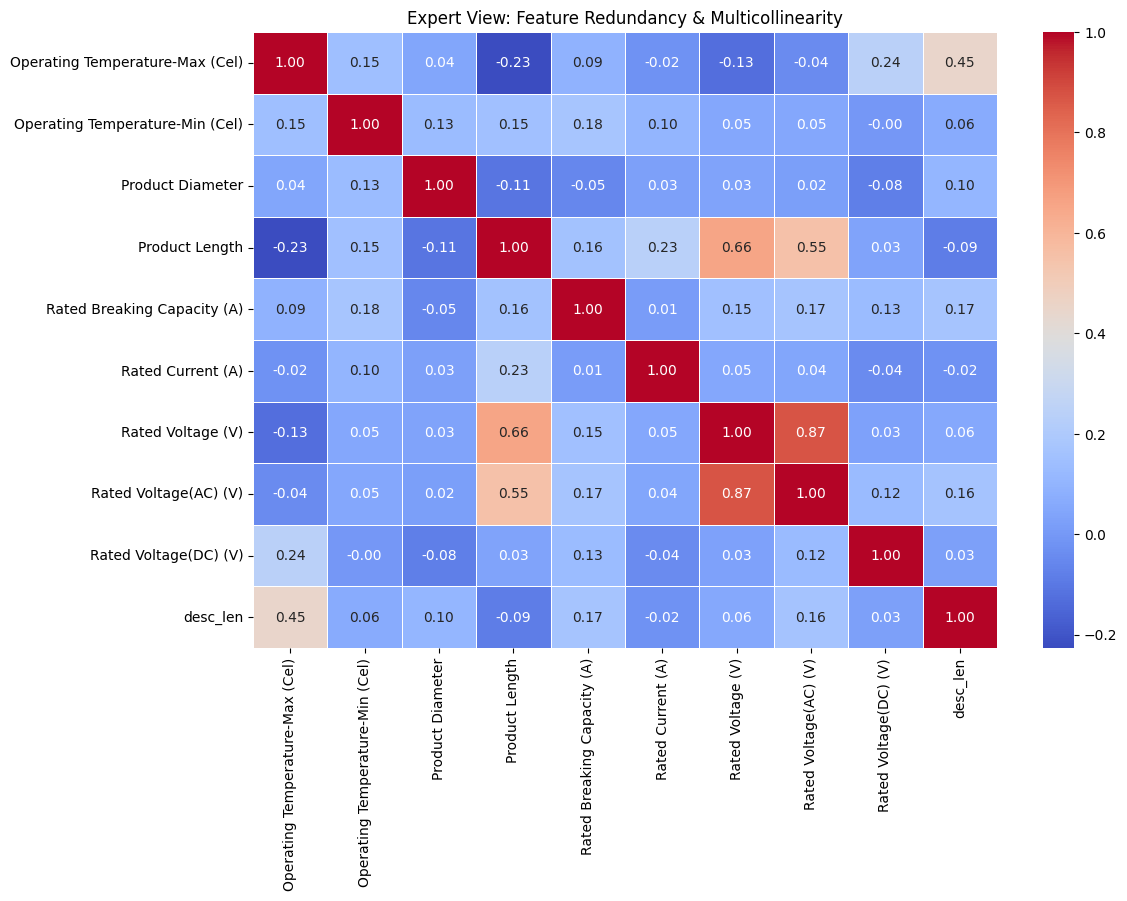

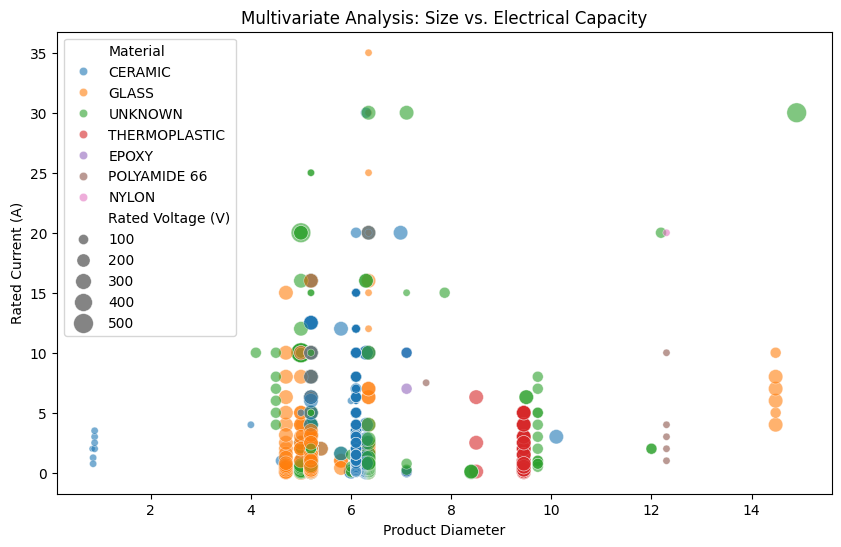

--- 🚨 Statistical Outlier Report ---
Rows with Z-Score > 3: 44 (4.41% of data)

--- 🤖 RAG Readiness Report ---
Description Uniqueness: 0.58
Average Information Density (Chars): 154.4
✅ Data is rich enough for direct embeddings.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Advanced Correlation Heatmap (Multicollinearity Check)
def plot_advanced_corr(df):
    num_df = df.select_dtypes(include=[np.number])
    corr_matrix = num_df.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Expert View: Feature Redundancy & Multicollinearity")
    plt.show()

# 2. Multivariate Physics Check (Scatter Analysis)
def physics_outlier_check(df):
    plt.figure(figsize=(10, 6))
    # Correlation between size and current is a physical law in fuses
    sns.scatterplot(data=df, x='Product Diameter', y='Rated Current (A)', 
                    hue='Material', size='Rated Voltage (V)', sizes=(20, 200), alpha=0.6)
    plt.title("Multivariate Analysis: Size vs. Electrical Capacity")
    plt.show()

# 3. Z-Score Statistical Outliers (Across Specs)
def detect_statistical_outliers(df):
    cols = ['Rated Current (A)', 'Rated Voltage (V)', 'Product Diameter']
    z = np.abs(stats.zscore(df[cols].fillna(0)))
    outlier_indices = np.where(z > 3)
    unique_outliers = len(set(outlier_indices[0]))
    print(f"--- 🚨 Statistical Outlier Report ---")
    print(f"Rows with Z-Score > 3: {unique_outliers} ({round(unique_outliers/len(df)*100, 2)}% of data)")
    return unique_outliers

# 4. RAG Readiness: Information Density
def check_rag_readiness(df):
    unique_ratio = df['DESCRIPTION'].nunique() / len(df)
    avg_desc_len = df['DESCRIPTION'].str.len().mean()
    print(f"\n--- 🤖 RAG Readiness Report ---")
    print(f"Description Uniqueness: {unique_ratio:.2f}")
    print(f"Average Information Density (Chars): {avg_desc_len:.1f}")
    
    if unique_ratio < 0.5 or avg_desc_len < 30:
        print("⚠️ WARNING: Sparse data detected. Need 'Text Enrichment' before Phase 2.")
    else:
        print("✅ Data is rich enough for direct embeddings.")

# Execution
plot_advanced_corr(df_final_clean)
physics_outlier_check(df_final_clean)
detect_statistical_outliers(df_final_clean)
check_rag_readiness(df_final_clean)